<a href="https://colab.research.google.com/github/vishal9198/genAi-Labs/blob/main/autouencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,models
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(x_train,_),(x_test,_)=tf.keras.datasets.mnist.load_data()

In [ ]:
x_train,x_test= x_train/255.0, x_test/255.0

In [ ]:
x_train=np.expand_dims(x_train,-1)
x_test=np.expand_dims(x_test,-1)
print(f"x_train shape {x_train.shape}")
print(f"x_test shape {x_test.shape}")

x_train shape (60000, 28, 28, 1)
x_test shape (10000, 28, 28, 1)


In [ ]:
encoder = models.Sequential([
    layers.InputLayer(input_shape=(28, 28, 1)),

    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        strides=2,
        padding='same'
    ),

    layers.Conv2D(
        64,
        (3, 3),
        activation='relu',
        strides=2,
        padding='same'
    ),

    layers.Flatten(),

    layers.Dense(
        64,
        activation='relu'
    )
])


decoder = models.Sequential([
    layers.InputLayer(input_shape=(64,)),

    layers.Dense(
        7 * 7 * 64,
        activation='relu'
    ),

    layers.Reshape((7, 7, 64)),

    layers.Conv2DTranspose(
        64,
        (3, 3),
        activation='relu',
        strides=2,
        padding='same'
    ),

    layers.Conv2DTranspose(
        32,
        (3, 3),
        activation='relu',
        strides=2,
        padding='same'
    ),

    layers.Conv2DTranspose(
        1,
        (3, 3),
        activation='sigmoid',
        padding='same'
    )
])


autoencoder = models.Sequential([
    encoder,
    decoder
])

autoencoder.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 64)             │       219,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28, 1)      │       259,521 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 479,105 (1.83 MB)

 Trainable params: 479,105 (1.83 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
encoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219,584 (857.75 KB)

 Trainable params: 219,584 (857.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
decoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 3136)           │       203,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,521 (1013.75 KB)

 Trainable params: 259,521 (1013.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [ ]:
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=128,
                validation_data=(x_test, x_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 117s 235ms/step - loss: 0.1609 - val_loss: 0.0860
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 101s 215ms/step - loss: 0.0808 - val_loss: 0.0763
Epoch 3/10
212/469 ━━━━━━━━━━━━━━━━━━━━ 53s 210ms/step - loss: 0.0764

KeyboardInterrupt: 

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


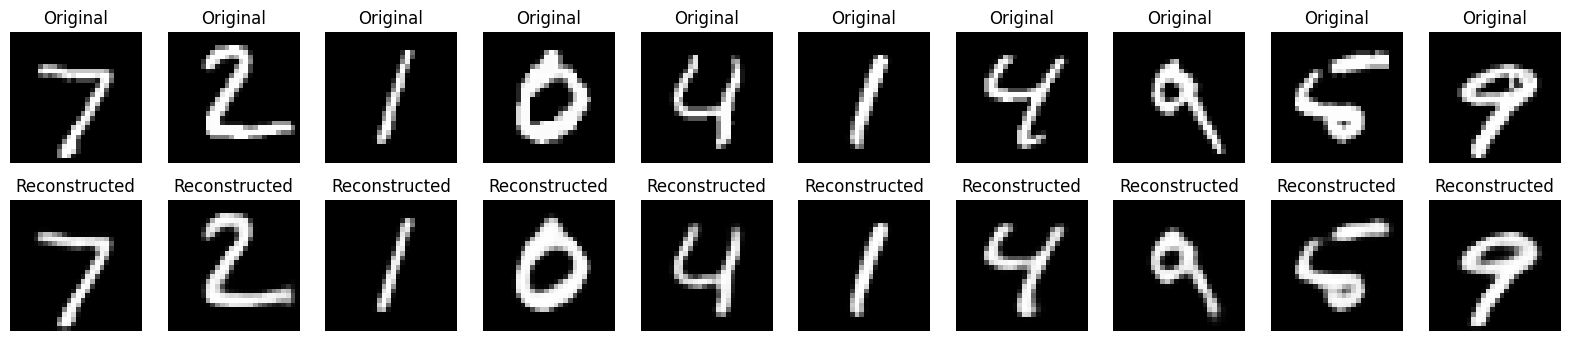

In [ ]:
decoded_images = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))

for i in range(n):

    # Original Images
    ax = plt.subplot(2, n, i + 1)

    plt.imshow(
        x_test[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title("Original")
    plt.gray()
    ax.axis('off')


    # Reconstructed Images
    ax = plt.subplot(2, n, i + 1 + n)

    plt.imshow(
        decoded_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title("Reconstructed")
    plt.gray()
    ax.axis('off')

plt.show()